# Research: Performance in Major Marathons
Research notebook for analyzing the performance within the major marathons.  This should give a more stable basis for comparison, with less noise from outlier marathons.

In [4]:
# Load featurized_race_data_v2.csv and necessary analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Load data
print("Loading race data...")
df = pd.read_csv('../data/featurized_race_data_v3.csv')
bq_ages = pd.read_csv('../data/boston_marathon_qualifying.csv')

print(f"Total records loaded: {len(df):,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Extract year and filter to 2004-2024
df['year'] = pd.to_datetime(df['date']).dt.year
df_filtered = df[(df['year'] >= 2004) & (df['year'] <= 2026)].copy()

# Filter to valid sex values
df_filtered = df_filtered[df_filtered['sex'].isin(['M', 'F'])]

print(f"\nFiltered to 2004-2024: {len(df_filtered):,} records")
print(f"Years covered: {sorted(df_filtered['year'].unique())}")

# Create age bracket function based on Boston qualifying ranges
def get_age_bracket(age):
    """Map age to Boston Marathon qualifying age bracket"""
    if pd.isna(age) or age < 18:
        return None
    elif age <= 34: return '18-34'
    elif age <= 39: return '35-39'
    elif age <= 44: return '40-44'
    elif age <= 49: return '45-49'
    elif age <= 54: return '50-54'
    elif age <= 59: return '55-59'
    elif age <= 64: return '60-64'
    elif age <= 69: return '65-69'
    elif age <= 74: return '70-74'
    elif age <= 79: return '75-79'
    else: return '80+'

# Define age bracket order for consistent plotting
age_bracket_order = ['18-34', '35-39', '40-44', '45-49', '50-54', 
                     '55-59', '60-64', '65-69', '70-74', '75-79', '80+']

df_filtered['age_bracket'] = df_filtered['age'].apply(get_age_bracket)

# Remove records with no age bracket
df_filtered = df_filtered[df_filtered['age_bracket'].notna()]

print(f"\nAfter filtering valid ages and sex: {len(df_filtered):,} records")
print(f"Sex distribution: {df_filtered['sex'].value_counts().to_dict()}")
print(f"Age bracket distribution:")
print(df_filtered['age_bracket'].value_counts().sort_index())

# Use this filtered dataframe for all analyses
df = df_filtered

Loading race data...
Total records loaded: 1,857,106
Date range: 2000-01-08 to 2023-12-31

Filtered to 2004-2024: 1,606,927 records
Years covered: [np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]

After filtering valid ages and sex: 1,348,534 records
Sex distribution: {'M': 756999, 'F': 591535}
Age bracket distribution:
age_bracket
18-34    644849
35-39    206513
40-44    171127
45-49    128585
50-54     91079
55-59     55718
60-64     29976
65-69     13384
70-74      5296
75-79      1434
80+         573
Name: count, dtype: int64


In [27]:
df_explore = pd.DataFrame(df_filtered.groupby('race').size(), columns=["racers"]).reset_index().sort_values(by="racers", ascending=False)
df_explore["cumulative_racers"] = df_explore['racers'].cumsum()
df_explore["pct_coverage"] = (df_explore["cumulative_racers"] / df_explore["racers"].sum()) * 100.0
display(df_explore.head(6))

races_to_include = set(df_explore.head(6)["race"].to_list())
print("Including the following races:")
display(races_to_include)
print(f"Total Coverage: {df_explore.head(6)["pct_coverage"].max()}%")

,race,racers,cumulative_racers,pct_coverage
181,city_of_los_angeles_marathon_(l.a._marathon),103913,103913,7.705627
171,chicago_marathon,93697,197610,14.653691
557,marine_corps_marathon,80712,278322,20.638857
666,new_york_city_marathon,76483,354805,26.310423
121,boston_marathon,67505,422310,31.316229
741,philadelphia_marathon,45020,467330,34.654669


Including the following races:


{'boston_marathon',
 'chicago_marathon',
 'city_of_los_angeles_marathon_(l.a._marathon)',
 'marine_corps_marathon',
 'new_york_city_marathon',
 'philadelphia_marathon'}

Total Coverage: 34.65466944103745%


In [28]:
df_filtered = df[df["race"].isin(races_to_include)]
df = df_filtered
display(df)

,age,sex,time,race,date,city,state,full_temp_min,full_temp_max,full_temp_median_min,...,full_overall_weekend_days_of_precip,peak_temp_min,peak_temp_max,peak_temp_median_min,peak_temp_median_max,peak_overall_precip,peak_overall_days_of_precip,peak_overall_weekend_days_of_precip,year,age_bracket
116473,27.0,F,244.633333,boston_marathon,2004-04-19,albuquerque,nm,17.4,81.1,32.40,...,8,32.0,81.1,43.05,68.85,66.6,9,4,2004,18-34
116474,28.0,F,284.000000,boston_marathon,2004-04-19,albuquerque,nm,17.4,81.1,32.40,...,8,32.0,81.1,43.05,68.85,66.6,9,4,2004,18-34
116475,46.0,F,308.716667,boston_marathon,2004-04-19,albuquerque,nm,17.4,81.1,32.40,...,8,32.0,81.1,43.05,68.85,66.6,9,4,2004,45-49
116476,39.0,F,195.700000,boston_marathon,2004-04-19,albuquerque,nm,17.4,81.1,32.40,...,8,32.0,81.1,43.05,68.85,66.6,9,4,2004,35-39
116477,53.0,M,251.983333,boston_marathon,2004-04-19,albuquerque,nm,17.4,81.1,32.40,...,8,32.0,81.1,43.05,68.85,66.6,9,4,2004,50-54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1382915,24.0,M,344.383333,philadelphia_marathon,2023-11-19,washington,dc,31.3,98.3,55.55,...,11,31.3,81.3,41.70,64.95,17.6,8,3,2023,18-34
1382916,25.0,F,279.000000,philadelphia_marathon,2023-11-19,washington,dc,31.3,98.3,55.55,...,11,31.3,81.3,41.70,64.95,17.6,8,3,2023,18-34
1382917,25.0,F,278.800000,philadelphia_marathon,2023-11-19,washington,dc,31.3,98.3,55.55,...,11,31.3,81.3,41.70,64.95,17.6,8,3,2023,18-34
1382918,51.0,F,227.933333,philadelphia_marathon,2023-11-19,westminster,co,5.3,98.4,44.50,...,6,5.3,83.6,32.30,61.10,21.5,4,2,2023,50-54


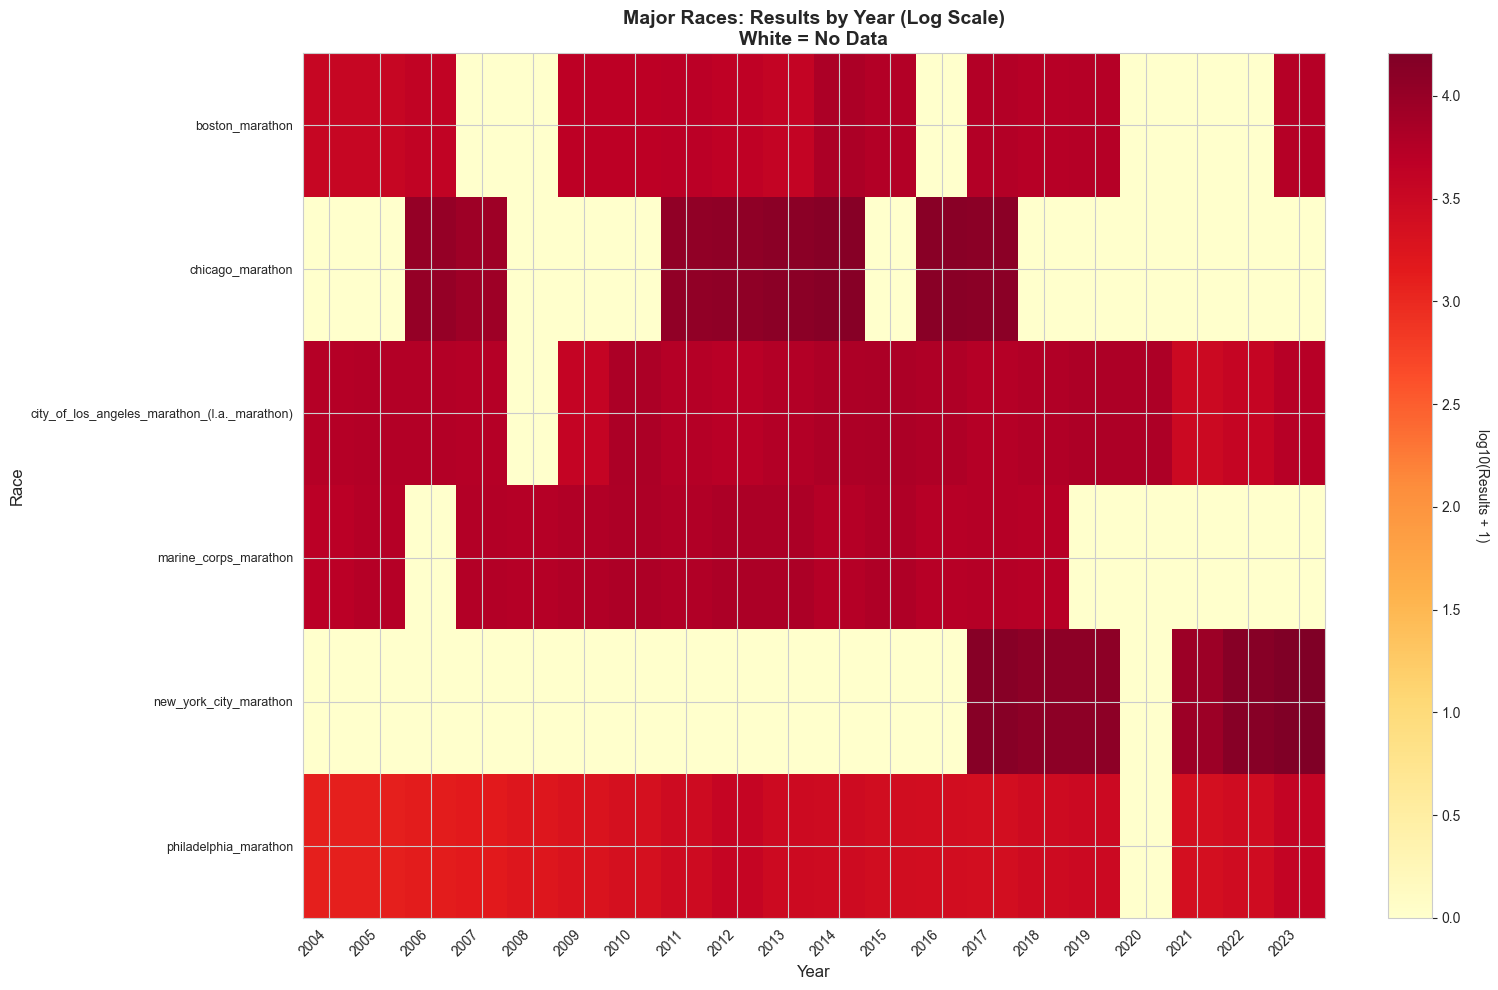

In [30]:
race_year_pivot = df.groupby(['race', 'year']).size().unstack(fill_value=0)

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 10))

# Use log scale for better visualization (since counts vary widely)
# Add 1 to avoid log(0)
heatmap_data = np.log10(race_year_pivot + 1)

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# Set ticks
ax.set_xticks(range(len(race_year_pivot.columns)))
ax.set_xticklabels(race_year_pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(race_year_pivot.index)))
ax.set_yticklabels(race_year_pivot.index, fontsize=9)

ax.set_title('Major Races: Results by Year (Log Scale)\nWhite = No Data', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Race', fontsize=12)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('log10(Results + 1)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()